In [27]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk
import re
import pytz
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score

nltk.download('vader_lexicon', quiet=True) # Download VADER lexicon silently

True

In [28]:
base_dir = '/Users/kimminseo/Downloads/ml/'
reddit_data_dir = os.path.join(base_dir, 'reddit_data/')
stock_data_dir = os.path.join(base_dir, 'stock_data/')

refined_comments_output_file = os.path.join(reddit_data_dir, 'reddit_wsb_comments.csv')

focused_start_date = '2020-09-29' 
focused_end_date = '2022-02-14'   

reddit_post_files = {
    'wsb': os.path.join(reddit_data_dir, 'reddit_wsb.csv'),
    'rGME': os.path.join(reddit_data_dir, 'rGME_dataset_features.csv'),
    'rDDintoGME': os.path.join(reddit_data_dir, 'rDDintoGME_dataset_features.csv'),
    'rGMEJungle': os.path.join(reddit_data_dir, 'rGMEJungle_dataset_features.csv'),
    'rsuperstonk': os.path.join(reddit_data_dir, 'rsuperstonk_dataset_features.csv')
}
consolidated_posts_output_file = os.path.join(reddit_data_dir, 'all_reddit_posts_consolidated.csv')

In [29]:
print("--- Consolidate Reddit Post Data ---")

sid = SentimentIntensityAnalyzer()
all_posts_dfs = []
desired_final_post_columns = [
    'id', 'title', 'author', 'score', 'num_comments', 'timestamp_utc', 'subreddit',
    'clean_text', 'compound', 'neg', 'neu', 'pos'
]

for subreddit_name, file_path in reddit_post_files.items():
    print(f"Loading {subreddit_name} posts...")
    if not os.path.exists(file_path):
        continue
    
    try:
        df = pd.read_csv(file_path, low_memory=False)
        df['subreddit'] = subreddit_name

        if 'date' in df.columns:
            df['timestamp_utc'] = pd.to_datetime(df['date'], errors='coerce')
        elif 'created' in df.columns:
            df['timestamp_utc'] = pd.to_datetime(df['created'], unit='s', errors='coerce')
        elif 'created_utc' in df.columns:
             df['timestamp_utc'] = pd.to_datetime(df['created_utc'], unit='s', errors='coerce') 
        else:
            df['timestamp_utc'] = pd.NaT

        for col in ['score', 'num_comments']:
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)
            else:
                df[col] = 0

        if 'clean_text' not in df.columns:
            if 'title' in df.columns:
                df['clean_text'] = df['title'].astype(str).str.lower().str.replace(r'[^a-zA-Z0-9\s]', '', regex=True)
        df['clean_text'] = df['clean_text'].astype(str)

        has_precomputed_sentiment = all(s_col in df.columns for s_col in ['compound', 'neg', 'neu', 'pos'])
        
        if not has_precomputed_sentiment:
            df_sentiment_source = df.dropna(subset=['clean_text']).copy()
            df_sentiment_source = df_sentiment_source[df_sentiment_source['clean_text'].astype(str).str.strip() != '']

            if not df_sentiment_source.empty:
                df.loc[df_sentiment_source.index, 'compound'] = df_sentiment_source['clean_text'].apply(lambda x: sid.polarity_scores(x)['compound'])
                df.loc[df_sentiment_source.index, 'neg'] = df_sentiment_source['clean_text'].apply(lambda x: sid.polarity_scores(x)['neg'])
                df.loc[df_sentiment_source.index, 'neu'] = df_sentiment_source['clean_text'].apply(lambda x: sid.polarity_scores(x)['neu'])
                df.loc[df_sentiment_source.index, 'pos'] = df_sentiment_source['clean_text'].apply(lambda x: sid.polarity_scores(x)['pos'])
        
        sentiment_cols = ['compound', 'neg', 'neu', 'pos'] 
        for s_col in sentiment_cols:
            if s_col not in df.columns: 
                df[s_col] = 0.0
            df[s_col] = pd.to_numeric(df[s_col], errors='coerce').fillna(0.0)

        df_selected = df.reindex(columns=desired_final_post_columns)
        all_posts_dfs.append(df_selected)

    except Exception as e:
        print(f"Error processing {subreddit_name}: {e}. Skipping.")

if all_posts_dfs:
    df_all_reddit_posts = pd.concat(all_posts_dfs, ignore_index=True)
    
    if 'timestamp_utc' in df_all_reddit_posts.columns and not df_all_reddit_posts['timestamp_utc'].empty:
        df_all_reddit_posts_temp_indexed = df_all_reddit_posts.set_index('timestamp_utc').sort_index()
        df_all_reddit_posts_filtered = df_all_reddit_posts_temp_indexed.loc[focused_start_date:focused_end_date].reset_index()
    else:
        df_all_reddit_posts_filtered = pd.DataFrame()

    if not df_all_reddit_posts_filtered.empty:
        df_all_reddit_posts_filtered.to_csv(consolidated_posts_output_file, index=False)

print("--- VERIFYING df_all_reddit_posts_filtered ---")
if 'df_all_reddit_posts_filtered' in locals() and not df_all_reddit_posts_filtered.empty:
    print("Subreddits in filtered data:")
    print(df_all_reddit_posts_filtered['subreddit'].value_counts(dropna=False))
else:
    print("df_all_reddit_posts_filtered is empty or not found.")

--- Consolidate Reddit Post Data ---
Loading wsb posts...
Loading rGME posts...
Loading rDDintoGME posts...
Loading rGMEJungle posts...
Loading rsuperstonk posts...
--- VERIFYING df_all_reddit_posts_filtered ---
Subreddits in filtered data:
subreddit
rGME           1033236
rsuperstonk     560125
wsb              53187
rGMEJungle       39634
rDDintoGME        5498
Name: count, dtype: int64


In [30]:
print("--- Aggregating Daily Post Metrics Per Subreddit ---")

if 'df_all_reddit_posts_filtered' in locals() and not df_all_reddit_posts_filtered.empty:
    df_posts_indexed = df_all_reddit_posts_filtered.set_index('timestamp_utc').sort_index()

    df_daily_subreddit_posts = df_posts_indexed.groupby('subreddit').resample('D').agg(
        daily_post_count=('id', 'size'),
        daily_avg_sentiment=('compound', 'mean')
    ).reset_index()

    df_daily_subreddit_posts.rename(columns={'subreddit': 'Subreddit'}, inplace=True)
    df_daily_subreddit_posts['daily_avg_sentiment'].fillna(0, inplace=True)

else:
    print("df_all_reddit_posts_filtered is empty or not found.")

--- Aggregating Daily Post Metrics Per Subreddit ---


In [31]:
print("--- Loading and Preparing GME Stock Data ---")

gme_stock_file_path = os.path.join(stock_data_dir, 'GameStop.csv') 

if not os.path.exists(gme_stock_file_path):
    print(f"Error: GME stock file not found at '{gme_stock_file_path}'.")
else:
    try:
        df_gme = pd.read_csv(gme_stock_file_path)
        df_gme['Date'] = pd.to_datetime(df_gme['Date'])
        df_gme.set_index('Date', inplace=True)
        
        df_gme_daily = df_gme[['Open', 'Close', 'Volume']].resample('D').mean()
        df_gme_daily.fillna(method='ffill', inplace=True)
        
        if 'df_daily_subreddit_posts' in locals() and not df_daily_subreddit_posts.empty:
            gme_filter_start_date = df_daily_subreddit_posts['timestamp_utc'].min()
            gme_filter_end_date = df_daily_subreddit_posts['timestamp_utc'].max()
        else:
            gme_filter_start_date = focused_start_date
            gme_filter_end_date = focused_end_date

        df_gme_daily_filtered = df_gme_daily.loc[gme_filter_start_date:gme_filter_end_date].copy()

    except Exception as e:
        print(f"Error loading or preparing GME stock data: {e}")
        df_gme_daily_filtered = pd.DataFrame()

--- Loading and Preparing GME Stock Data ---


In [32]:
print("--- Merging All Subreddit Metrics with GME Stock Data ---")

if 'df_gme_daily_filtered' in locals() and not df_gme_daily_filtered.empty and \
   'df_daily_subreddit_posts' in locals() and not df_daily_subreddit_posts.empty:
    
    df_combined_all_metrics = df_gme_daily_filtered.copy()

    df_daily_post_counts_pivot_all = df_daily_subreddit_posts.pivot(
        index='timestamp_utc', 
        columns='Subreddit', 
        values='daily_post_count'
    )
    df_daily_post_counts_pivot_all.columns = [f'daily_post_count_{col}' for col in df_daily_post_counts_pivot_all.columns]

    df_daily_sentiment_pivot_all = df_daily_subreddit_posts.pivot(
        index='timestamp_utc', 
        columns='Subreddit', 
        values='daily_avg_sentiment'
    )
    df_daily_sentiment_pivot_all.columns = [f'daily_avg_sentiment_{col}' for col in df_daily_sentiment_pivot_all.columns]

    df_combined_all_metrics = df_combined_all_metrics.merge(
        df_daily_post_counts_pivot_all, 
        left_index=True, 
        right_index=True, 
        how='left'
    )

    df_combined_all_metrics = df_combined_all_metrics.merge(
        df_daily_sentiment_pivot_all, 
        left_index=True, 
        right_index=True, 
        how='left'
    )

    df_combined_all_metrics.fillna(0, inplace=True)

else:
    print("Required DataFrames not found or are empty.")

--- Merging All Subreddit Metrics with GME Stock Data ---


--- Generating Report Figures 3 & 4 ---


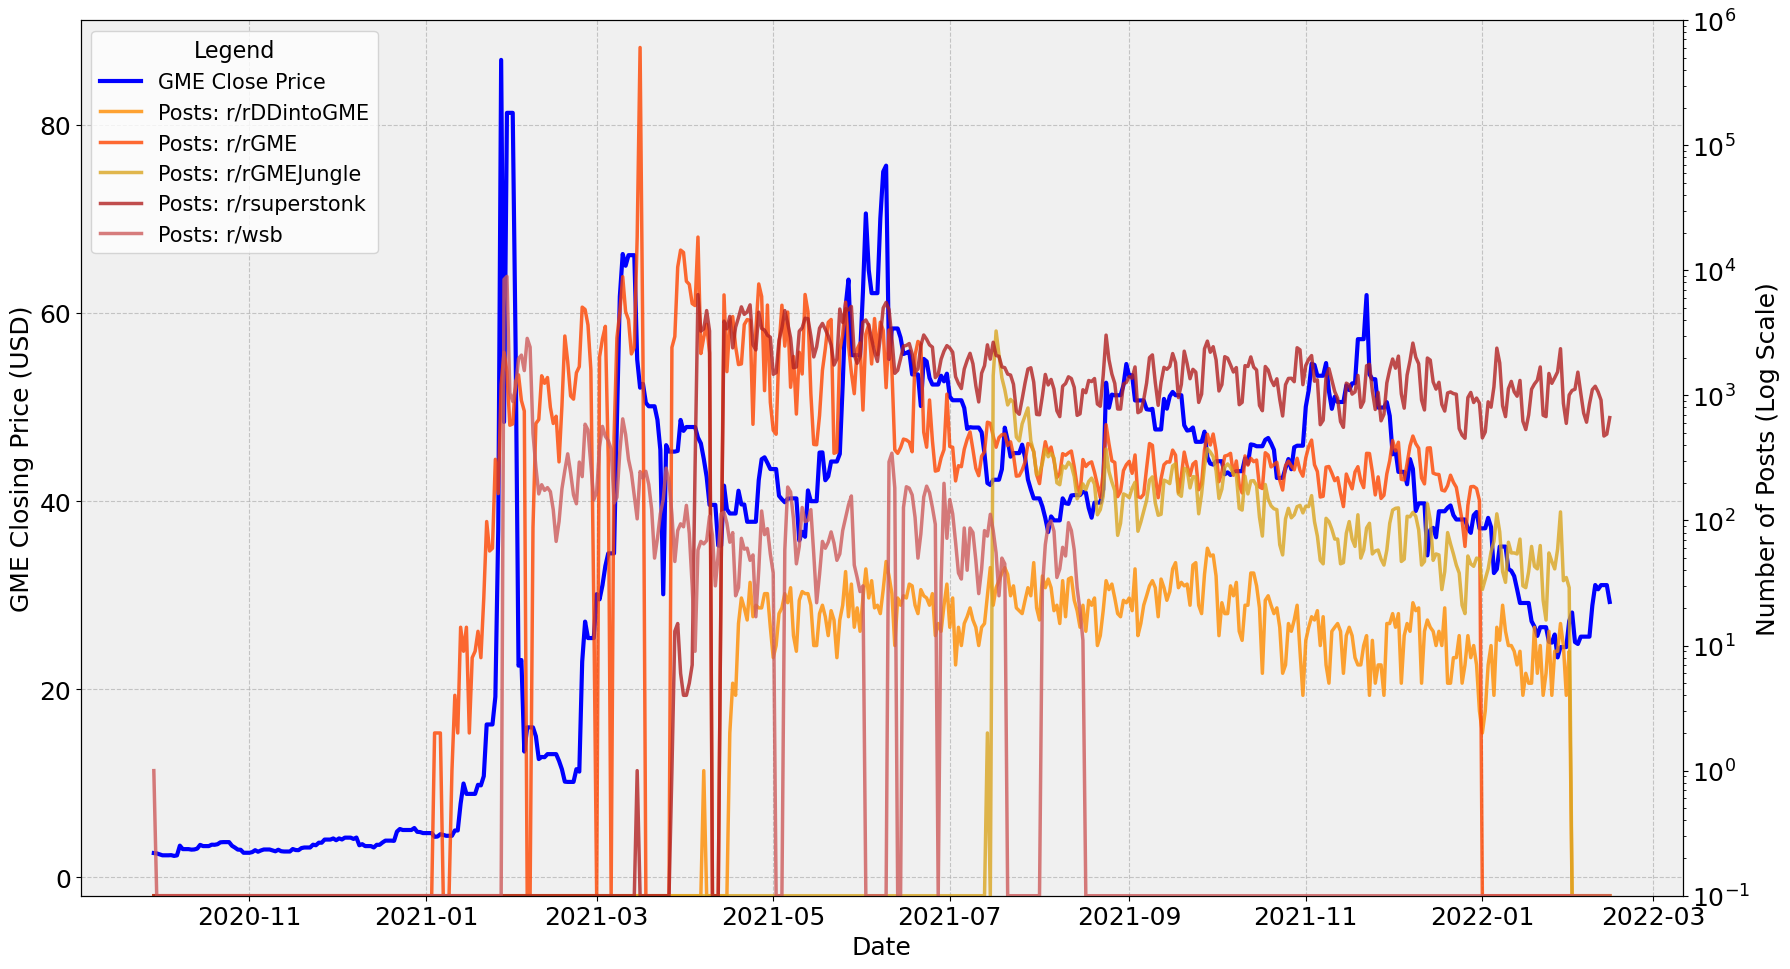

Report Figure 3 (GME Close Price & All Reddit Post Volume) generated.


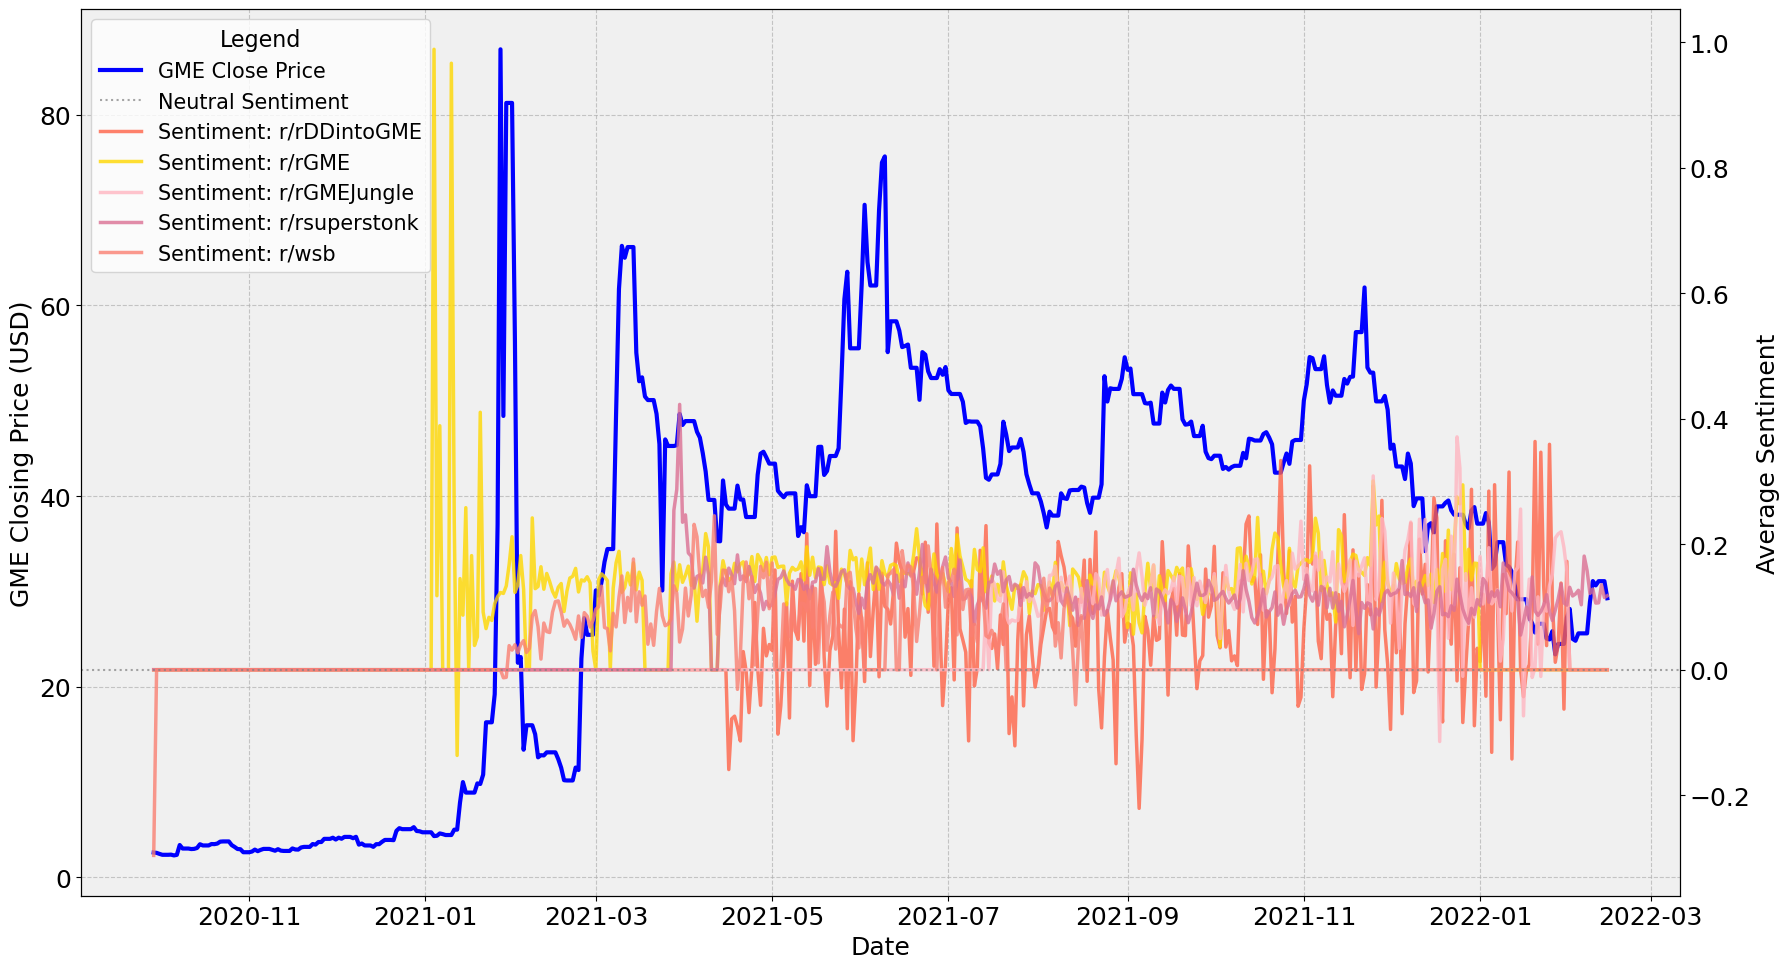

Report Figure 4 (GME Close Price & All Reddit Average Sentiment) generated.


In [33]:
print("--- Generating Report Figures 3 & 4 ---")

if 'df_combined_all_metrics' in locals() and not df_combined_all_metrics.empty:
    df_plot_data = df_combined_all_metrics.sort_index().copy()

    if 'df_all_reddit_posts_filtered' in locals() and not df_all_reddit_posts_filtered.empty:
        all_subreddits_for_plot = sorted(df_all_reddit_posts_filtered['subreddit'].unique().tolist())
    else:
        all_subreddits_for_plot = [col.replace('daily_post_count_', '') 
                                   for col in df_plot_data.columns 
                                   if col.startswith('daily_post_count_')]
    
    # Figure 3: GME Price & Reddit Post Volume
    fig_price_posts, ax1_price_posts = plt.subplots(figsize=(18, 10))

    ax1_price_posts.plot(df_plot_data.index, df_plot_data['Close'], label='GME Close Price', color='#0000FF', linewidth=3, zorder=2)
    ax1_price_posts.set_ylabel('GME Closing Price (USD)', fontsize=18)
    ax1_price_posts.tick_params(axis='y', which='major', labelsize=18)
    ax1_price_posts.grid(True, linestyle='--', alpha=0.7, zorder=1)
    ax1_price_posts.set_xlabel('Date', fontsize=18)
    ax1_price_posts.tick_params(axis='x', which='major', labelsize=18)
    ax1_price_posts.set_facecolor('#f0f0f0')

    ax2_price_posts = ax1_price_posts.twinx()
    ax2_price_posts.set_ylabel('Number of Posts (Log Scale)', fontsize=18)
    ax2_price_posts.tick_params(axis='y', which='major', labelsize=18)
    
    post_volume_colors = ['#FF8C00', '#FF4500', '#DAA520', '#B22222', '#CD5C5C']
    
    for i, sub in enumerate(all_subreddits_for_plot):
        col_name = f'daily_post_count_{sub}'
        if col_name in df_plot_data.columns:
            plot_data = df_plot_data[col_name].replace(0, 0.1)
            ax2_price_posts.plot(df_plot_data.index, plot_data, 
                                 label=f'Posts: r/{sub}', 
                                 color=post_volume_colors[i % len(post_volume_colors)], 
                                 linestyle='-', 
                                 alpha=0.8, linewidth=2.5, zorder=1)

    ax2_price_posts.set_yscale('log')
    ax2_price_posts.set_ylim(0.1, 10**6)

    lines, labels = ax1_price_posts.get_legend_handles_labels()
    lines2, labels2 = ax2_price_posts.get_legend_handles_labels()
    ax2_price_posts.legend(lines + lines2, labels + labels2, loc='upper left', fontsize=15, title='Legend', title_fontsize=16)

    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()
    print("Report Figure 3 (GME Close Price & All Reddit Post Volume) generated.")

    # Figure 4: GME Price & Reddit Average Sentiment
    fig_price_sentiment, ax1_price_sentiment = plt.subplots(figsize=(18, 10))

    ax1_price_sentiment.plot(df_plot_data.index, df_plot_data['Close'], label='GME Close Price', color='#0000FF', linewidth=3, zorder=2)
    ax1_price_sentiment.set_ylabel('GME Closing Price (USD)', fontsize=18)
    ax1_price_sentiment.tick_params(axis='y', which='major', labelsize=18)
    ax1_price_sentiment.grid(True, linestyle='--', alpha=0.7, zorder=1)
    ax1_price_sentiment.set_xlabel('Date', fontsize=18)
    ax1_price_sentiment.tick_params(axis='x', which='major', labelsize=18)
    ax1_price_sentiment.set_facecolor('#f0f0f0')
    
    ax2_price_sentiment = ax1_price_sentiment.twinx()
    ax2_price_sentiment.set_ylabel('Average Sentiment', fontsize=18)
    ax2_price_sentiment.tick_params(axis='y', which='major', labelsize=18)
    ax2_price_sentiment.axhline(y=0, color='grey', linestyle=':', alpha=0.7, label='Neutral Sentiment', zorder=2)

    sentiment_colors = ['#FF6347', '#FFD700', '#FFB6C1', '#DB7093', '#FA8072']
    
    for i, sub in enumerate(all_subreddits_for_plot):
        col_name = f'daily_avg_sentiment_{sub}'
        if col_name in df_plot_data.columns:
            ax2_price_sentiment.plot(df_plot_data.index, df_plot_data[col_name], 
                                     label=f'Sentiment: r/{sub}', 
                                     color=sentiment_colors[i % len(sentiment_colors)], 
                                     linestyle='-', 
                                     alpha=0.8, linewidth=2.5, zorder=1)
            
    lines_s, labels_s = ax1_price_sentiment.get_legend_handles_labels()
    lines2_s, labels2_s = ax2_price_sentiment.get_legend_handles_labels()
    ax2_price_sentiment.legend(lines_s + lines2_s, labels_s + labels2_s, loc='upper left', fontsize=15, title='Legend', title_fontsize=16)

    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()
    print("Report Figure 4 (GME Close Price & All Reddit Average Sentiment) generated.")

else:
    print("df_combined_all_metrics DataFrame not found or is empty.")

In [38]:
print("--- Prepare Data for Predictive Modeling ---")

if 'df_combined_all_metrics' in locals() and not df_combined_all_metrics.empty:
    df_ml_data_all = df_combined_all_metrics.copy()

    # Target Definition
    df_ml_data_all['GME_Close_Pct_Change'] = df_ml_data_all['Close'].pct_change() * 100
    df_ml_data_all['Target_GME_Next_Day_Pct_Change'] = df_ml_data_all['GME_Close_Pct_Change'].shift(-1)
    df_ml_data_all['GME_Open_Pct_Change'] = df_ml_data_all['Open'].pct_change() * 100
    df_ml_data_all['Target_GME_Next_Day_Open_Pct_Change'] = df_ml_data_all['GME_Open_Pct_Change'].shift(-1)
    
    # Feature Engineering
    all_subreddit_features = [col for col in df_ml_data_all.columns if col.startswith('daily_post_count_') or col.startswith('daily_avg_sentiment_')]

    lag_days = [1, 3]
    rolling_windows = [3, 7]

    for feature in all_subreddit_features:
        for lag in lag_days:
            df_ml_data_all[f'{feature}_lag_{lag}d'] = df_ml_data_all[feature].shift(lag)

    for feature in all_subreddit_features:
        for window in rolling_windows:
            df_ml_data_all[f'{feature}_rolling_mean_{window}d'] = df_ml_data_all[feature].rolling(window=window).mean().shift(1) 
            df_ml_data_all[f'{feature}_rolling_std_{window}d'] = df_ml_data_all[feature].rolling(window=window).std().shift(1) 

    features_to_use_for_ml = [
        'Volume', 'Open', 'Close', 'GME_Close_Pct_Change', 'GME_Open_Pct_Change'
    ] + all_subreddit_features 

    for feature in all_subreddit_features:
        for lag in lag_days:
            features_to_use_for_ml.append(f'{feature}_lag_{lag}d')
        for window in rolling_windows:
            features_to_use_for_ml.append(f'{feature}_rolling_mean_{window}d')
            features_to_use_for_ml.append(f'{feature}_rolling_std_{window}d')

    initial_rows = len(df_ml_data_all)
    df_ml_data_all.dropna(subset=['Target_GME_Next_Day_Pct_Change'] + features_to_use_for_ml, inplace=True)
    
    X = df_ml_data_all[features_to_use_for_ml]
    y_close_pct = df_ml_data_all['Target_GME_Next_Day_Pct_Change']
    y_open_pct = df_ml_data_all['Target_GME_Next_Day_Open_Pct_Change']

else:
    print("df_combined_all_metrics is empty or not found.")

--- Prepare Data for Predictive Modeling ---


In [39]:
print("--- Apply Machine Learning Models ---")

if 'X' in locals() and 'y_close_pct' in locals() and not X.empty and not y_close_pct.empty:
    split_point = int(len(X) * 0.8)
    X_train, X_test = X.iloc[:split_point], X.iloc[split_point:]
    y_train, y_test = y_close_pct.iloc[:split_point], y_close_pct.iloc[split_point:]

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    models = {
        "Linear Regression": LinearRegression(),
        "Random Forest Regressor": RandomForestRegressor(random_state=42),
        "Neural Network (MLP)": MLPRegressor(random_state=42, max_iter=1000),
        "XGBoost Regressor": xgb.XGBRegressor(objective='reg:squarederror', random_state=42),
        "Support Vector Regressor (SVR)": SVR() 
    }

    results = {}

    for name, model in models.items():
        print(f"Training {name}...")
        try:
            if name in ["Linear Regression", "Neural Network (MLP)", "Support Vector Regressor (SVR)", "XGBoost Regressor"]:
                model.fit(X_train_scaled, y_train)
                y_pred = model.predict(X_test_scaled)
            else: 
                model.fit(X_train, y_train) 
                y_pred = model.predict(X_test)

            mse = mean_squared_error(y_test, y_pred)
            rmse = mean_squared_error(y_test, y_pred, squared=False) 
            r2 = r2_score(y_test, y_pred)

            results[name] = {"MSE": mse, "RMSE": rmse, "R2": r2}

            print(f"{name} Evaluation: MSE={mse:.4f}, RMSE={rmse:.4f}, R2={r2:.4f}")

        except Exception as e:
            print(f"Error training {name}: {e}")
            results[name] = {"Error": str(e)}

    print("\n--- All Model Results Summary ---")
    for name, metrics in results.items():
        if "Error" in metrics:
            print(f"{name}: Error - {metrics['Error']}")
        else:
            print(f"{name}: MSE={metrics['MSE']:.4f}, RMSE={metrics['RMSE']:.4f}, R2={metrics['R2']:.4f}")

--- Apply Machine Learning Models ---
Training Linear Regression...
Linear Regression Evaluation: MSE=57.6552, RMSE=7.5931, R2=-1.6551
Training Random Forest Regressor...
Random Forest Regressor Evaluation: MSE=35.5666, RMSE=5.9638, R2=-0.6379
Training Neural Network (MLP)...


/opt/anaconda3/envs/myenv/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Neural Network (MLP) Evaluation: MSE=103.2708, RMSE=10.1622, R2=-3.7557
Training XGBoost Regressor...
XGBoost Regressor Evaluation: MSE=41.6859, RMSE=6.4565, R2=-0.9197
Training Support Vector Regressor (SVR)...
Support Vector Regressor (SVR) Evaluation: MSE=22.1332, RMSE=4.7046, R2=-0.0193

--- All Model Results Summary ---
Linear Regression: MSE=57.6552, RMSE=7.5931, R2=-1.6551
Random Forest Regressor: MSE=35.5666, RMSE=5.9638, R2=-0.6379
Neural Network (MLP): MSE=103.2708, RMSE=10.1622, R2=-3.7557
XGBoost Regressor: MSE=41.6859, RMSE=6.4565, R2=-0.9197
Support Vector Regressor (SVR): MSE=22.1332, RMSE=4.7046, R2=-0.0193
